# Pretrained-Model

In this file a pretrained model is used to extract features from the hand images after which a fully connected network is utilized to categorize the images based on the extracted features. EfficientNetB3 is the pretrainded convolutional neural network used as a robust backbone in this assignment. Several versions of the EfficientNet model were tested and B3 was found to be the optimal size for this task.

The model is trained with the same images preprocessed in the same way to ensure consistency between the models.

## Data preparation

In [2]:
import os
import glob
import keras

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input, BatchNormalization, MaxPooling2D

In [3]:
base_dir = ''

train_dir = os.path.join(base_dir, 'Train')
val_dir = os.path.join(base_dir, 'Test')
test_dir = os.path.join(base_dir, 'Validation')

one_dir = os.path.join(train_dir, '1')
two_dir = os.path.join(train_dir, '2')
three_dir = os.path.join(train_dir, '3')
four_dir = os.path.join(train_dir, '4')
five_dir = os.path.join(train_dir, '5')

one_imgs = os.listdir(one_dir)
two_imgs = os.listdir(two_dir)
three_imgs = os.listdir(three_dir)
four_imgs = os.listdir(four_dir)
five_imgs = os.listdir(five_dir)

In [4]:
BATCH_SIZE = 24
TARGET_SIZE = 300
EPOCHS = 300

The data is prepared the same way it was in the CNN-model.

In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True
)

validation_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [6]:
train_generator = train_datagen.flow_from_directory(train_dir, 
                                                    target_size=(TARGET_SIZE, TARGET_SIZE), 
                                                    batch_size=BATCH_SIZE, 
                                                    shuffle=True,
                                                    class_mode='categorical')

val_generator = validation_test_datagen.flow_from_directory(val_dir,
                                                       target_size=(TARGET_SIZE, TARGET_SIZE), 
                                                       batch_size=BATCH_SIZE, 
                                                       shuffle=True,
                                                       class_mode='categorical')

test_generator = validation_test_datagen.flow_from_directory(test_dir,
                                                  target_size=(TARGET_SIZE, TARGET_SIZE),
                                                  batch_size=BATCH_SIZE,
                                                  shuffle=False,
                                                  class_mode='categorical',
)

Found 210 images belonging to 5 classes.
Found 45 images belonging to 5 classes.
Found 45 images belonging to 5 classes.


## Model

The model is constructed by combining a pre-trained EfficientNetB3 base with a custom classification head designed to handle the five specific finger classes. By setting include_top=False, the original image classification layers of EfficientNetB3 are removed, allowing the network to learn new task-specific classifications.

The custom classification head is a simple three-layer network with dropouts to combat overfitting.

In [7]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential

base_model = EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(TARGET_SIZE, TARGET_SIZE, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

The model is then compiled mostly the same way as the CNN-model but the learning rate is set to 0.00005 since the with a higher learning rate the model was found to be highly unstable.

In [8]:
model.compile(optimizer = keras.optimizers.Adam(learning_rate=0.00005),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,210,548 (42.76 MB)

 Trainable params: 427,013 (1.63 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

With the very complex EfficientNetB3 network as a base the training took a significant amount of time. Though this is in part caused by the limited processing power of the computer used to train the model. The patience parameter was also reduced from the CNN-model and the best weights were found at epoch 135. 

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    verbose=0,
    callbacks=[early_stop],
)

Epoch 143: early stopping
Restoring model weights from the end of the best epoch: 135.


## Results

As with the CNN-model the loss and accuracy values for both the training and validation sets were recorded at each epoch and plotted to allow for visual assessment of the model’s learning behavior.

From the plots it can be seen that the training was quite noisy but did reach a satisfactory plateau. There are no signs of overfitting.

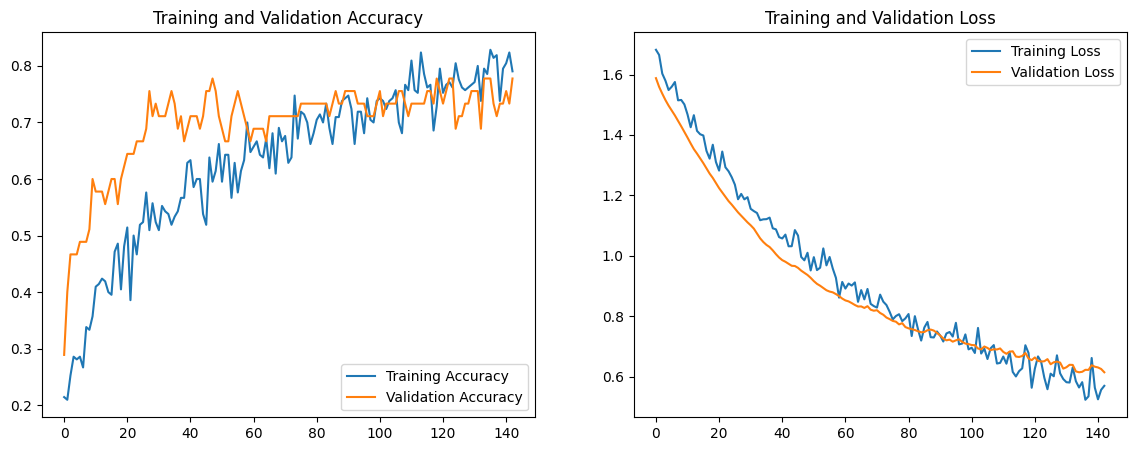

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

The model reached an accuracy of 78%, which is surprisingly low considering the use of a powerful feature extractor. This discrepancy suggests that the model may not be utilizing the pre-trained weights optimally or that the images are not suitable for the EfficientNetB3 network. Nevertheless, the model still classifies the images quite well when compared to a completely random result.

In [12]:
test_loss, test_acc = model.evaluate(val_generator, verbose=2)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

2/2 - 2s - 918ms/step - accuracy: 0.7778 - loss: 0.6142
Test loss: 0.6141912937164307
Test accuracy: 0.7777777910232544


From the condusion matrix we see much of the same as with the CNN-model. The model never makes a mistake of quessing more than a one finger away from the correct amount. It seems that recognizing adjacent finger counts appears to be a more challenging task than originally predicted. 

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step


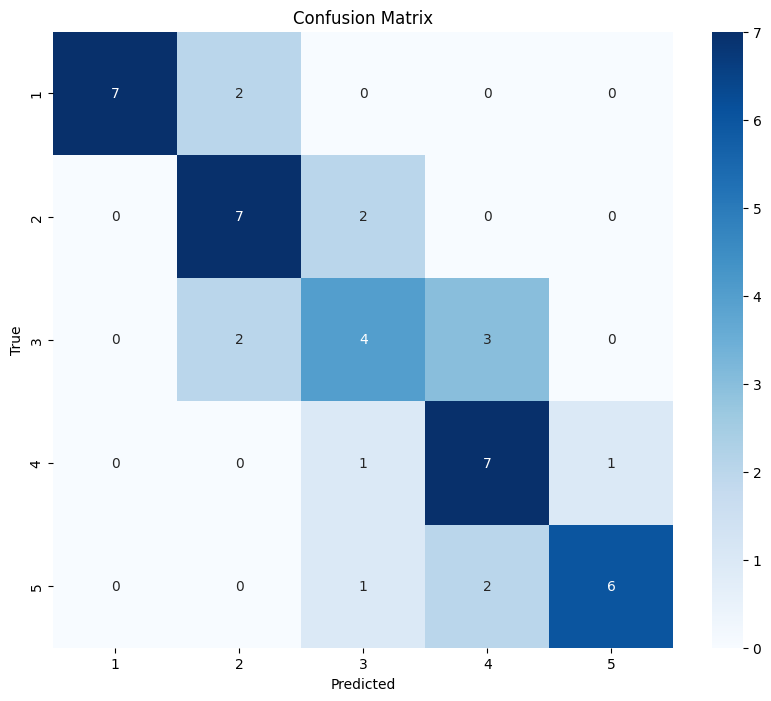

In [13]:
y_true_classes = test_generator.classes

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Below are examples comparing misclassified and correctly classified images, along with the corresponding probabilities assigned by the model.

Total misclassified images: 14 out of 45


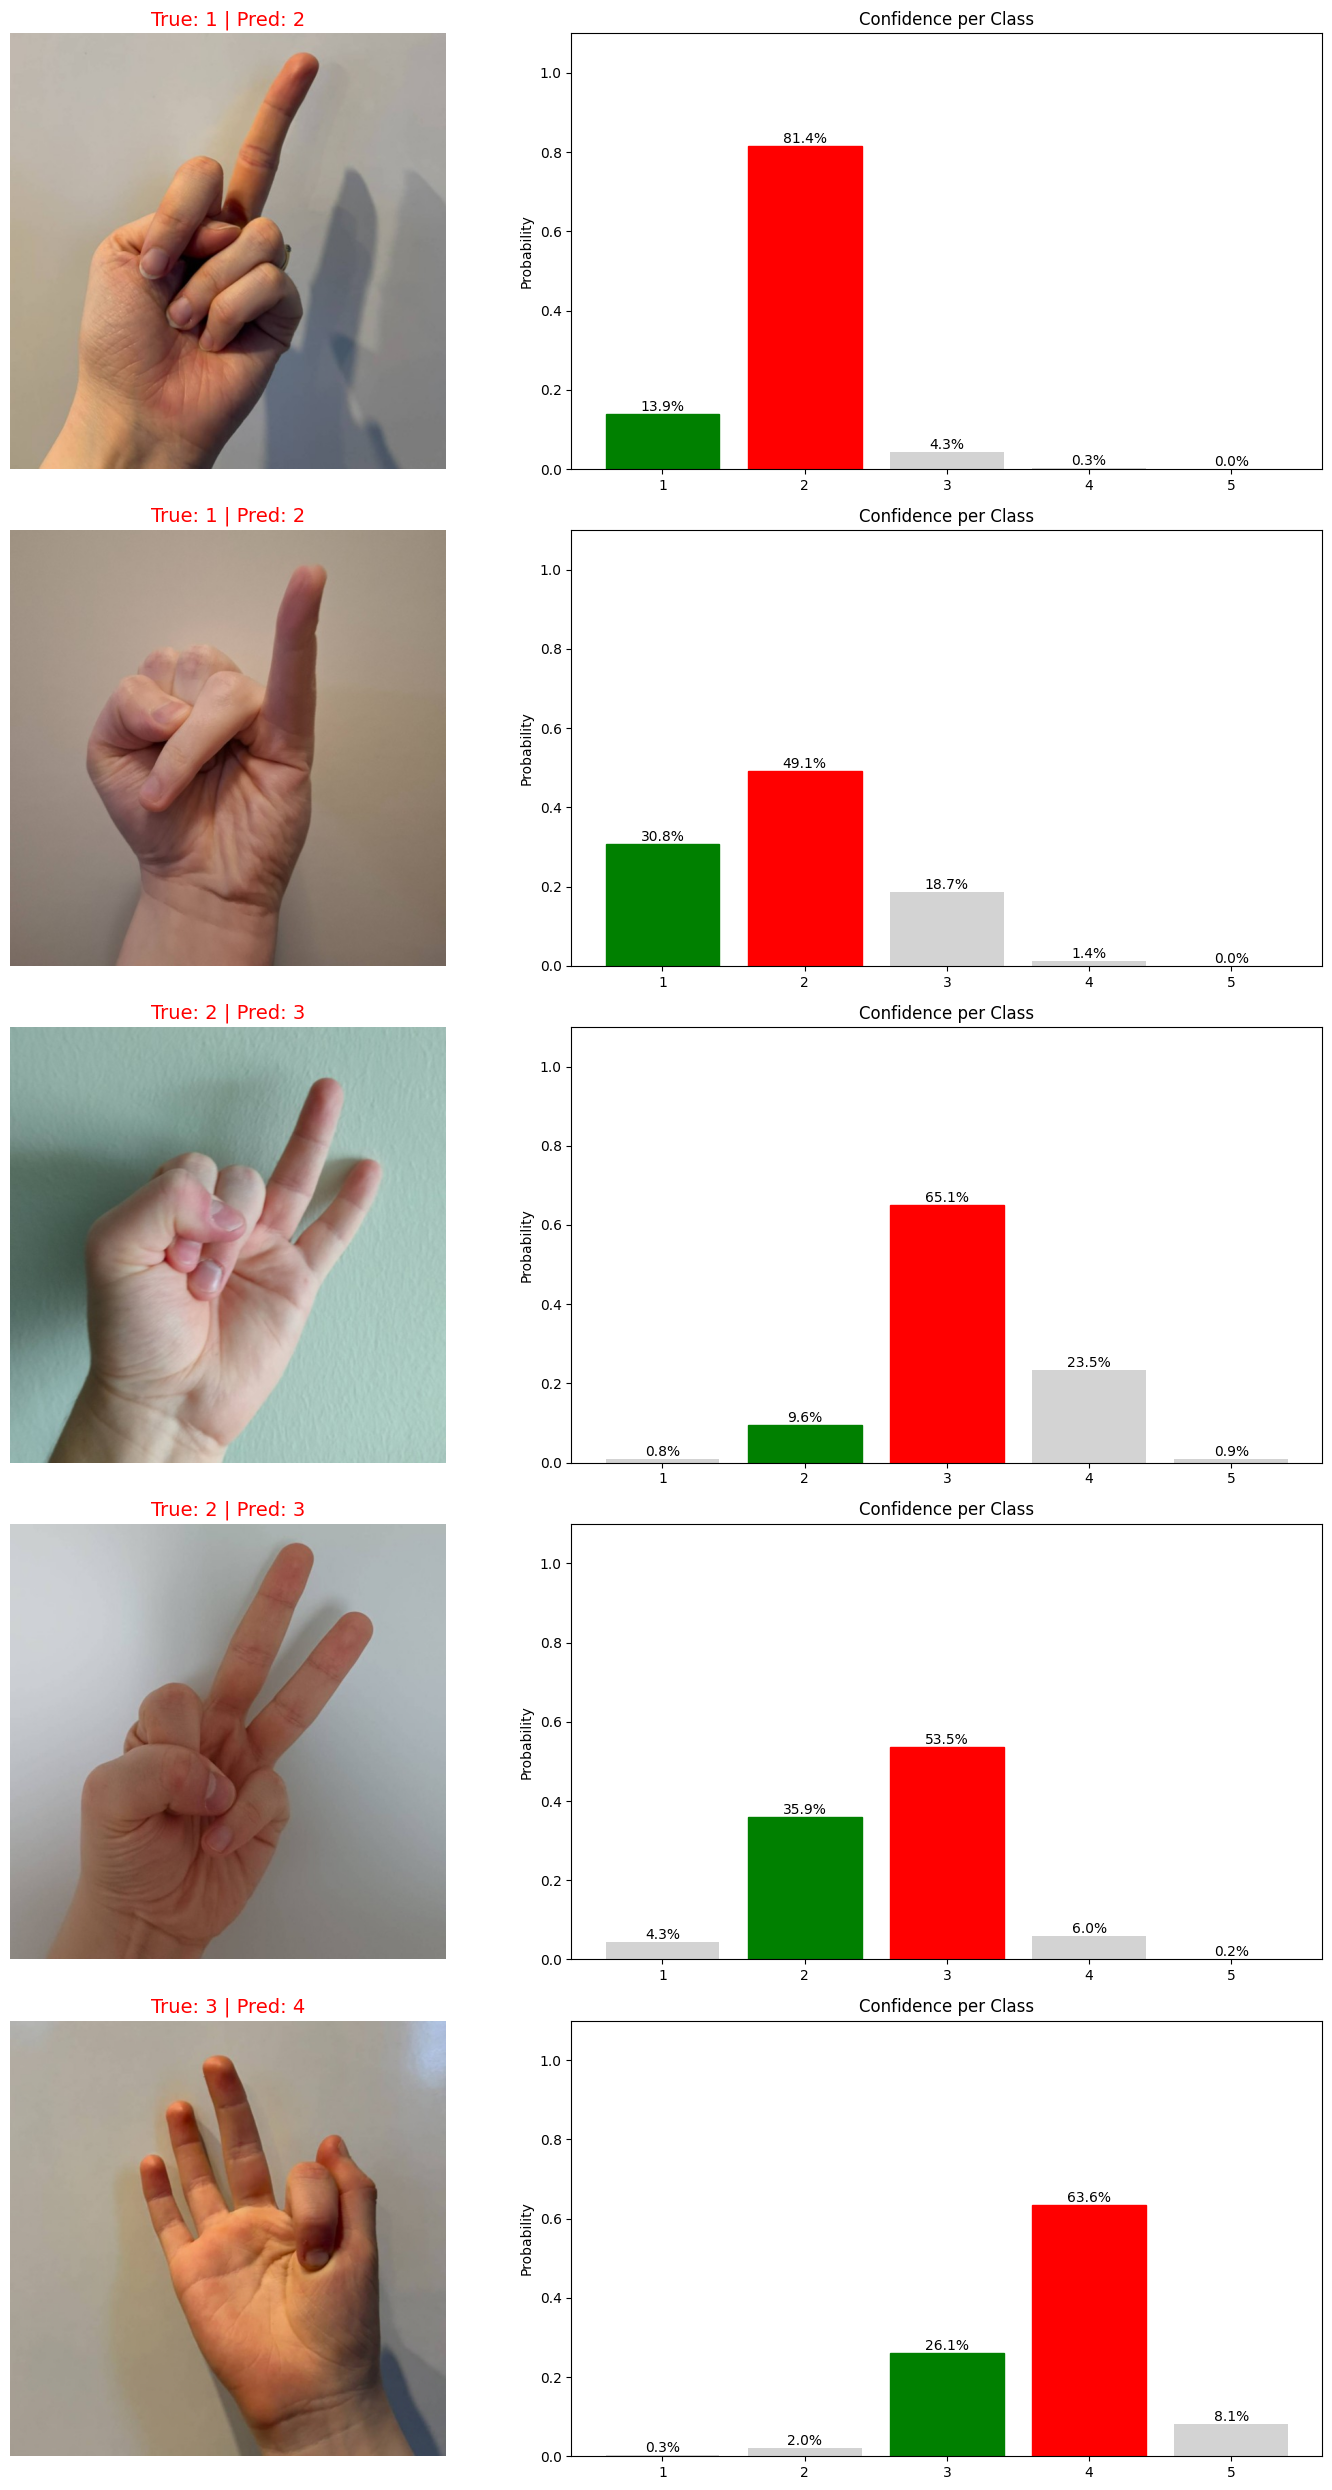

In [18]:
errors = np.where(y_pred_classes != y_true_classes)[0]

num_to_show = 5 
fig, axes = plt.subplots(num_to_show, 2, figsize=(15, 5 * num_to_show))

num_to_show = min(num_to_show, len(errors))

print(f"Total misclassified images: {len(errors)} out of {len(y_true_classes)}")

for i in range(num_to_show):
    idx = errors[i]
    
    img_path = os.path.join(test_generator.directory, test_generator.filenames[idx])
    img = plt.imread(img_path)
    
    axes[i, 0].imshow(img)
    true_label = class_names[y_true_classes[idx]]
    pred_label = class_names[y_pred_classes[idx]]
    axes[i, 0].set_title(f"True: {true_label} | Pred: {pred_label}", color='red', fontsize=14)
    axes[i, 0].axis('off')
    
    probabilities = y_pred[idx]
    
    bars = axes[i, 1].bar(class_names, probabilities, color='lightgray')
    
    true_idx = y_true_classes[idx]
    pred_idx = y_pred_classes[idx]
    
    bars[true_idx].set_color('green')
    bars[pred_idx].set_color('red')
    
    for bar in bars:
        height = bar.get_height()
        axes[i, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height*100:.1f}%', ha='center', va='bottom')

    axes[i, 1].set_ylim(0, 1.1)
    axes[i, 1].set_title("Confidence per Class", fontsize=12)
    axes[i, 1].set_ylabel("Probability")

plt.tight_layout()
plt.show()

Total correctly classified images: 31 out of 45


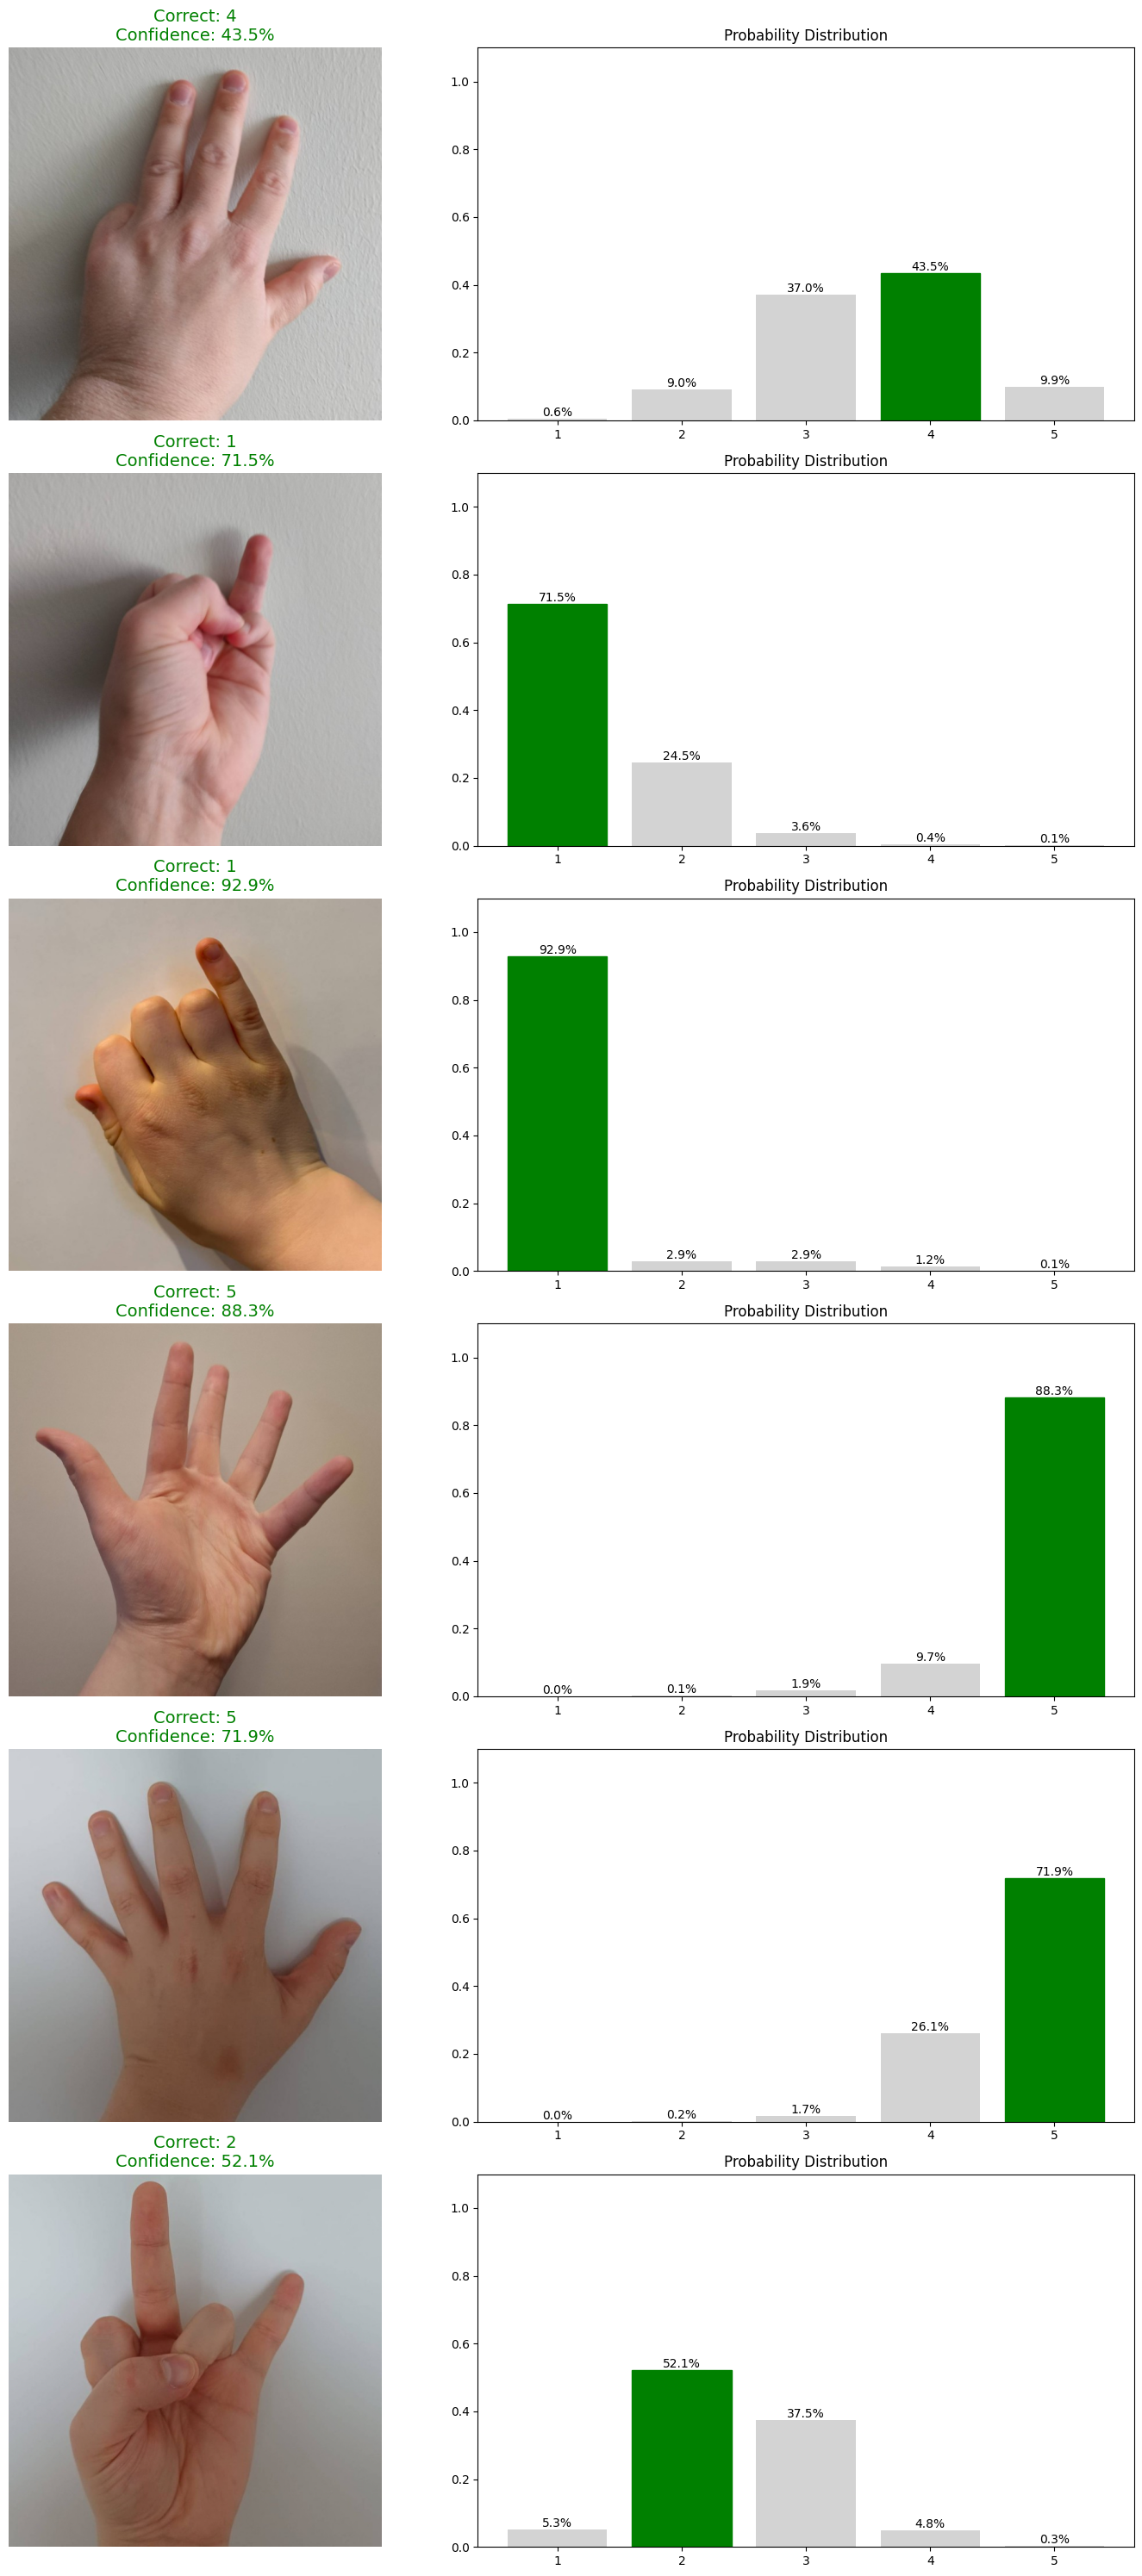

In [21]:
import numpy as np
import os
import matplotlib.pyplot as plt

corrects = np.where(y_pred_classes == y_true_classes)[0]
print(f"Total correctly classified images: {len(corrects)} out of {len(y_true_classes)}")

num_to_show = 6 
num_to_show = min(num_to_show, len(corrects))

random_corrects = np.random.choice(corrects, size=num_to_show, replace=False)

fig, axes = plt.subplots(num_to_show, 2, figsize=(15, 5 * num_to_show))

for i in range(num_to_show):
    idx = random_corrects[i]
    
    img_path = os.path.join(test_generator.directory, test_generator.filenames[idx])
    img = plt.imread(img_path)
    
    axes[i, 0].imshow(img)
    label = class_names[y_true_classes[idx]]
    confidence = y_pred[idx][y_true_classes[idx]] * 100
    
    axes[i, 0].set_title(f"Correct: {label}\nConfidence: {confidence:.1f}%", color='green', fontsize=14)
    axes[i, 0].axis('off')
    
    probabilities = y_pred[idx]
    bars = axes[i, 1].bar(class_names, probabilities, color='lightgray')
    
    correct_idx = y_true_classes[idx]
    bars[correct_idx].set_color('green')
    
    for bar in bars:
        height = bar.get_height()
        axes[i, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height*100:.1f}%', ha='center', va='bottom')

    axes[i, 1].set_ylim(0, 1.1)
    axes[i, 1].set_title("Probability Distribution", fontsize=12)

plt.tight_layout()
plt.show()